# Lidar autoencoder - harom architektura osszehasonlitasa

Harom modell tanul UGYANAZON az adaton. Mindharom TERBELI jellemzoterkepet
ad (nem lapitott vektort) - az RL sajat CNN feature-extractora dolgozza fel:

| modell | bemenet | mit tanul |
|---|---|---|
| `bev_ae` | nyers pontfelho | fix BEV statisztika (occupancy + z_max/z_min) -> conv AE |
| `graph_ae` | range image | dinamikus graf-konvolucio (EdgeConv) |
| `point_mae` | nyers pontfelho | maszkolt patch-rekonstrukcio (Transformer) |

## 1. Modulok, beallitasok

In [1]:
import gc
import glob
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

from lidar.point_mae import PointMAE, _chamfer_per_sample
from lidar.bev_ae import BEVConvAE
from lidar.graph_ae import LidarAE, DDCONFIG, points_to_range_image

DATA_DIR = "dataset/lidar"
EPOCHS = 40
N_FRAMES = None           # None = minden frame

N_POINTS = 24576

# A point_mae batch-e 128-rol 64-re ment. Ok: a num_group 128 -> 256 es a
# group_size 16 -> 32 (lasd a 6. szakaszt), ami a group() cdist-jet es a
# Chamfer tavolsagmatrixat is megnoveli. MERVE, ezen a 8.3 GB-os GPU-n:
#
#     batch 32 -> 5.9 GB    batch 64 -> 6.0 GB    batch 96 -> OOM
BATCH = {"bev_ae": 768, "graph_ae": 32, "point_mae": 100}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

print(DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
if torch.cuda.is_available():
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

cuda NVIDIA GeForce RTX 4080 SUPER
VRAM: 16.7 GB


In [2]:
def free_vram(*objects):
    for o in objects:
        if hasattr(o, "cpu"):
            o.cpu()
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def vram():
    """Aktualis GPU memoriahasznalat."""
    if not torch.cuda.is_available():
        return "n/a"
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    return (f"{torch.cuda.memory_allocated() / 1e9:.2f} GB foglalt / "
            f"{torch.cuda.memory_reserved() / 1e9:.2f} GB fenntartva / "
            f"{total:.1f} GB osszes")


print("indulaskor:", vram())

indulaskor: 0.00 GB foglalt / 0.00 GB fenntartva / 16.7 GB osszes


## 2. Adatok betoltese

**Harmas vagas (70 / 15 / 15), a szokasos szereposztassal:**

| halmaz | mire valo | ki latja |
|---|---|---|
| **train** | a sulyok tanulasa | a gradiens |
| **val** | early stopping, a legjobb epoch kivalasztasa | a DONTESEINK |
| **test** | a vegso, elfogulatlan meres | **csak egyszer, a legvegen** |

In [3]:
PATHS = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))
if N_FRAMES:
    PATHS = PATHS[:N_FRAMES]

# A keveres KOTELEZO: a framek idorendben keszultek, vagas elott a val/test
# a felvetel utolso szakasza lenne - mas utszakasz, mas forgalom, mint a train.
PERM = np.random.default_rng(0).permutation(len(PATHS))

VAL_FRAC, TEST_FRAC = 0.15, 0.15
N_TEST = int(len(PATHS) * TEST_FRAC)
N_VAL = int(len(PATHS) * VAL_FRAC)
N_TRAIN = len(PATHS) - N_VAL - N_TEST

print(f"{len(PATHS)} frame   train {N_TRAIN}   val {N_VAL}   test {N_TEST}")
print(f"RAM egy reprezentaciora: pontfelho "
      f"{len(PATHS) * N_POINTS * 3 * 4 / 1e9:.1f} GB, "
      f"range image {len(PATHS) * 64 * 512 * 4 / 1e9:.1f} GB")

50051 frame   train 35037   val 7507   test 7507
RAM egy reprezentaciora: pontfelho 14.8 GB, range image 6.6 GB


In [4]:
def _load(shape, fill, which=("train", "val"), workers=16):
    from concurrent.futures import ThreadPoolExecutor

    # A permutacio elso N_TEST eleme a test, utana N_VAL a val, a tobbi train.
    spans = {"test": (0, N_TEST),
             "val": (N_TEST, N_TEST + N_VAL),
             "train": (N_TEST + N_VAL, len(PATHS))}

    out = []
    for name in which:
        lo, hi = spans[name]
        idx = PERM[lo:hi]
        arr = np.empty((len(idx), *shape), dtype=np.float32)

        def read_one(k):
            arr[k] = fill(np.load(PATHS[idx[k]]), idx[k])

        with ThreadPoolExecutor(max_workers=workers) as ex:
            list(tqdm(ex.map(read_one, range(len(idx))), total=len(idx),
                      desc=f"{name:5s}", unit="frame"))
        out.append(torch.from_numpy(arr))
    return out


def load_clouds(which=("train", "val")):
    def fill(pts, idx):
        sel = np.random.default_rng(idx).choice(
            len(pts), N_POINTS, replace=len(pts) < N_POINTS)
        return pts[sel]
    return _load((N_POINTS, 3), fill, which)


def load_ranges(which=("train", "val")):
    # Az alakot a fuggvenytol kerdezzuk, nem beegetve: a TopoLiDM config
    # 64x1024-et ir elo, de ha ez valtozik, ez a cella nem szall el.
    shape = points_to_range_image(np.load(PATHS[0])).shape
    return _load(shape, lambda pts, idx: points_to_range_image(pts), which)


def drop(*names):
    """Tenzorok eldobasa a RAM-bol. A `del` utan a gc szabaditja fel."""
    for n in names:
        globals().pop(n, None)
    gc.collect()

### Mit tanulunk?

Harom veletlen frame, haromfele nezetben - pontosan az, amit a modellek
bemenetkent kapnak. Ehhez ideiglenesen betoltunk nehany frame-et.

BEV racs 128x128, 0.8 m cella   |   framek: [np.int64(23682), np.int64(25616), np.int64(37796)]


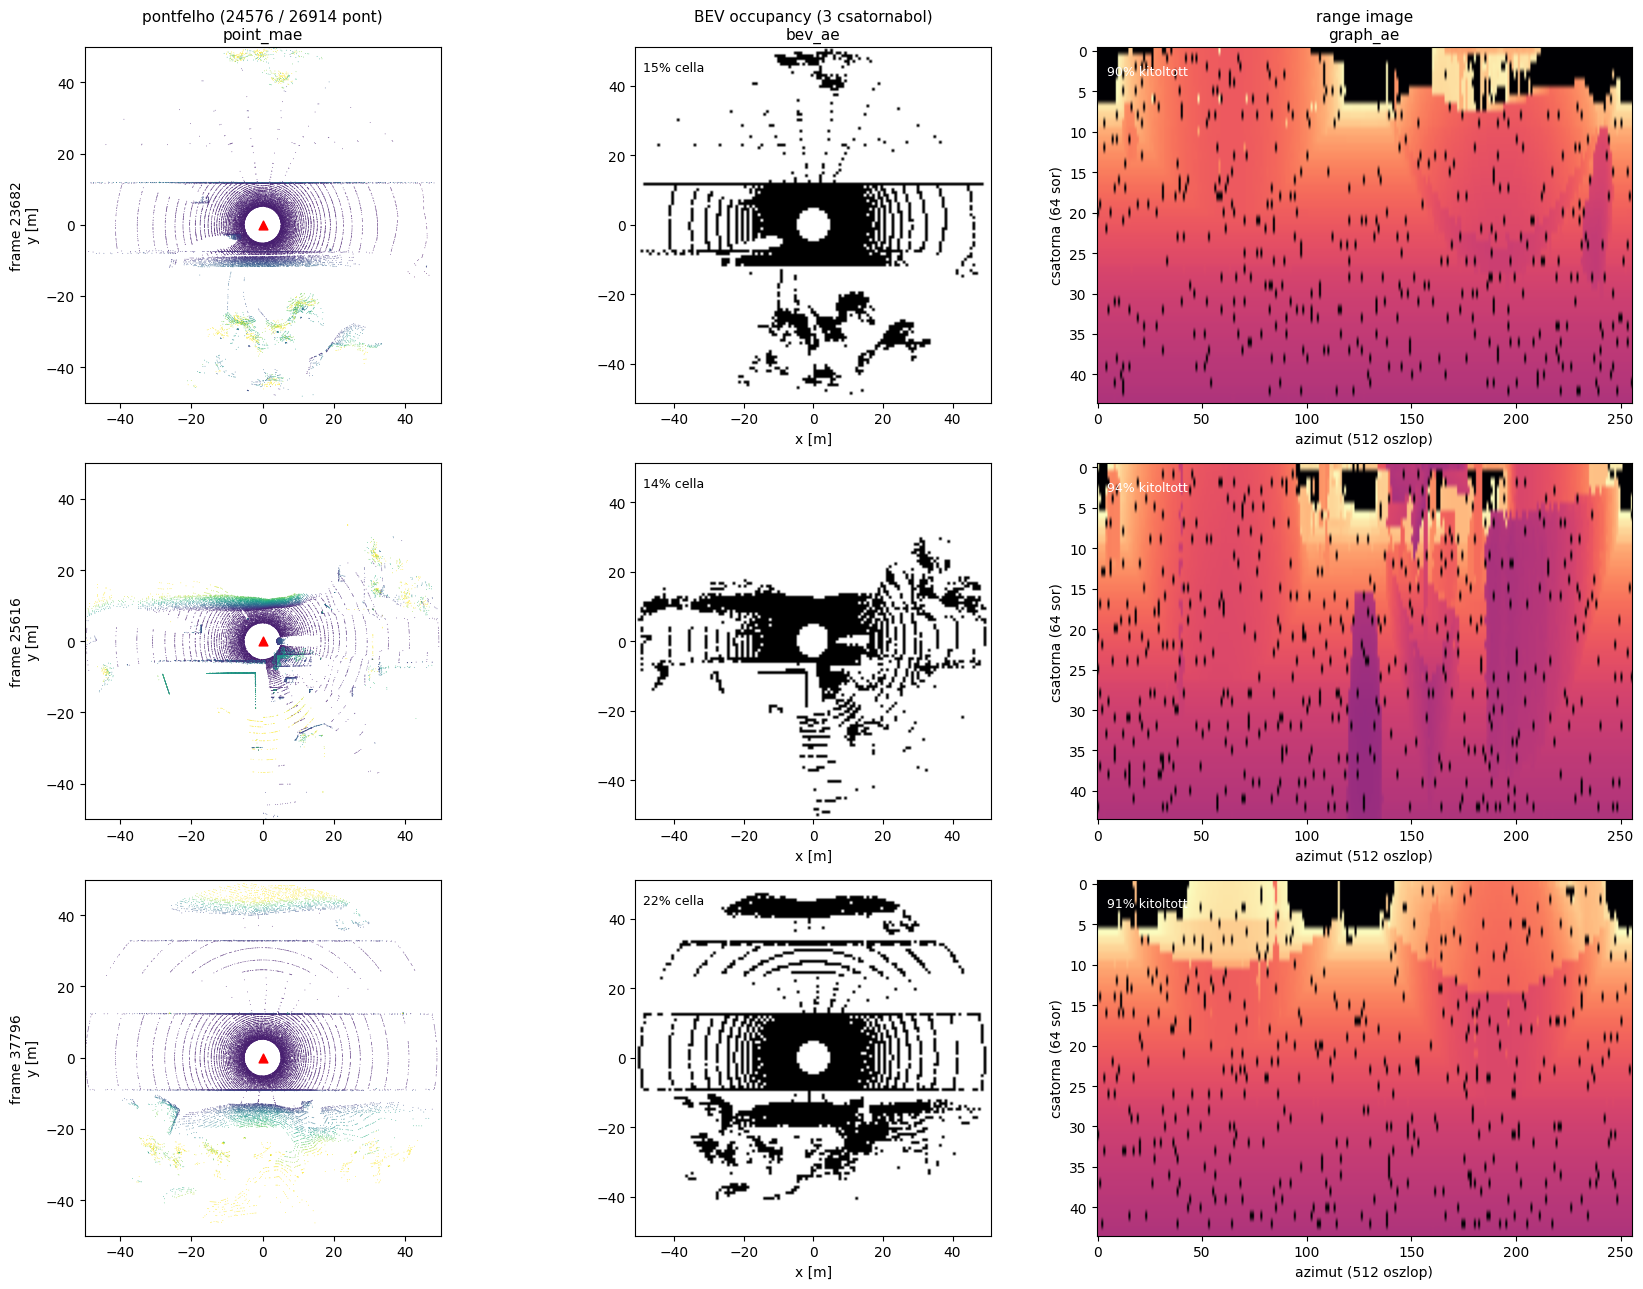

In [5]:
# Csak a megjelenitendo framek - nem a teljes adat.
SHOW_IDX = sorted(np.random.default_rng(1).choice(len(PATHS), 3, replace=False))
_show_raw = [np.load(PATHS[i]) for i in SHOW_IDX]
_show_pts = [torch.from_numpy(
    a[np.random.default_rng(i).choice(len(a), N_POINTS,
                                      replace=len(a) < N_POINTS)].astype(np.float32))
    for i, a in zip(SHOW_IDX, _show_raw)]

# A BEV statisztika fix keplet, nem tanult jellemzoterkep - egy friss
# modellpeldany is a vegleges kepet adja.
_probe = BEVConvAE().eval()
print(f"BEV racs {_probe.grid_h}x{_probe.grid_w}, "
      f"{_probe.hparams.voxel_size} m cella   |   framek: {SHOW_IDX}")

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
for row, (idx, raw, pts) in enumerate(zip(SHOW_IDX, _show_raw, _show_pts)):
    frame = pts.numpy()

    ax = axes[row, 0]
    ax.scatter(frame[:, 0], frame[:, 1], c=frame[:, 2], s=0.3, cmap="viridis",
               vmin=-3, vmax=4, linewidths=0)
    ax.scatter([0], [0], c="red", s=40, marker="^")
    ax.set_xlim(-50, 50)
    ax.set_ylim(-50, 50)
    ax.set_aspect("equal")
    ax.set_ylabel(f"frame {idx}\ny [m]")
    if row == 0:
        ax.set_title(f"pontfelho ({len(frame)} / {len(raw)} pont)\npoint_mae",
                     fontsize=11)

    ax = axes[row, 1]
    with torch.no_grad():
        occ = _probe.to_bev(pts.unsqueeze(0))[0, 0].numpy()
    _r = _probe.hparams.pc_range          # a modell sajat hatosugara
    ax.imshow(occ, cmap="gray_r", origin="lower", extent=[-_r, _r, -_r, _r])
    ax.set_xlabel("x [m]")
    if row == 0:
        ax.set_title("BEV occupancy (3 csatornabol)\nbev_ae", fontsize=11)
    ax.text(0.02, 0.96, f"{100 * occ.mean():.0f}% cella", transform=ax.transAxes,
            fontsize=9, va="top")

    ax = axes[row, 2]
    ri = points_to_range_image(raw)[0]
    ax.imshow(ri, cmap="magma", aspect="auto", vmin=-1, vmax=1)
    ax.set_xlabel("azimut (512 oszlop)")
    ax.set_ylabel("csatorna (64 sor)")
    if row == 0:
        ax.set_title("range image\ngraph_ae", fontsize=11)
    ax.text(0.02, 0.95, f"{100 * (ri > -0.999).mean():.0f}% kitoltott",
            transform=ax.transAxes, color="white", fontsize=9, va="top")

plt.tight_layout()
plt.show()
free_vram(_probe)
drop("_show_raw")

### Interaktiv 3D nezet

Forgathato, nagyithato. Ez a NYERS pontfelho — amibol mindharom modell
bemenete keszul.

In [6]:
def show_3d(pts, title="", max_points=25000, size=1.2, extra=None,
            height=650):
    pts = pts.cpu().numpy() if hasattr(pts, "cpu") else np.asarray(pts)

    # Ritkitas, hogy a bongeszo ne akadjon meg.
    if len(pts) > max_points:
        sel = np.random.default_rng(0).choice(len(pts), max_points, replace=False)
        pts = pts[sel]

    traces = [go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers",
        marker=dict(size=size, color=pts[:, 2], colorscale="Viridis",
                    cmin=-3, cmax=4, opacity=0.85,
                    colorbar=dict(title="z [m]", thickness=12, len=0.6)),
        name=f"pontfelho ({len(pts)})",
        hovertemplate="x %{x:.1f}<br>y %{y:.1f}<br>z %{z:.1f}<extra></extra>",
    )]

    # Az auto helye: a lidar az origoban van (x=0, z=2.4 a szenzor magassaga,
    # de a pontok mar a szenzorhoz kepest vannak megadva).
    traces.append(go.Scatter3d(
        x=[0], y=[0], z=[0], mode="markers",
        marker=dict(size=6, color="red", symbol="diamond"),
        name="ego (lidar)", hoverinfo="name"))

    for e_pts, e_name, e_color, e_size in (extra or []):
        e_pts = e_pts.cpu().numpy() if hasattr(e_pts, "cpu") else np.asarray(e_pts)
        traces.append(go.Scatter3d(
            x=e_pts[:, 0], y=e_pts[:, 1], z=e_pts[:, 2], mode="markers",
            marker=dict(size=e_size, color=e_color), name=e_name))

    fig = go.Figure(traces)
    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=0, r=0, t=40 if title else 0, b=0),
        legend=dict(x=0, y=1),
        scene=dict(
            # aspectmode="data": a harom tengely ARANYA a valos meretekbol
            # jon. Enelkul a plotly kockara nyujtja a jelenetet, es a lapos
            # ut-sik magasnak tunne.
            aspectmode="data",
            xaxis_title="x [m]  (elore)",
            yaxis_title="y [m]  (balra)",
            zaxis_title="z [m]  (fel)",
            # Kezdo kameraallas: kicsit hatulrol-felulrol, mint egy
            # kovetokamera - igy egybol felismerheto a jelenet.
            camera=dict(eye=dict(x=-1.4, y=-1.4, z=0.9)),
        ),
    )
    fig.show()

In [7]:
# Ugyanaz a harom frame 3D-ben, forgathatoan.
for idx, pts in zip(SHOW_IDX, _show_pts):
    show_3d(pts, title=f"frame {idx} - nyers pontfelho")

## 3. Kozos tanito fuggvenyek

A `train_model` **megszakithato es folytathato**: minden epoch vegen ment
(atomikusan, `.tmp` + atnevezes), es ujrainditaskor onnan folytatja, ahol
abbahagyta. Az optimizer allapota is mentodik — enelkul a folytatas nulla
lendulettel indulna, es az elso par epoch elrontana a tanulast.

In [8]:
def evaluate(model, data, batch, parts=False):
    """Atlagos loss a teljes adathalmazon.

    parts=True : (loss, dict) - a modell sajat diagnosztikaja is, atlagolva.
        EZ FONTOS: mindharom modellnel elofordult, hogy a loss szepen csokkent,
        kozben a modell mast tanult meg, mint amit akartunk:

          bev_ae     a loss 0.021-en allt, de az occupancy IoU csak 0.58 volt
                     (precision 0.59 - felmillio cella tevesen foglalt)
          point_mae  a Chamfer 4.74, a trivialis patch-atlag 4.79 -> a modell
                     KOLLAPSZALT, minden patch-re kb. ugyanazt adta. Az OK a
                     normalizalas hianya volt (lasd a 6. szakaszt); a modell
                     most a `gain_pct` diagnosztikat is visszaadja, ami pont
                     ezt a viszonyt meri epochonkent.
          graph_ae   az L1 nagy reszet az URES teruletek tettek ki

        Egyetlen szambol ezek egyike sem latszik.
    """
    model.eval()
    total, n, acc = 0.0, 0, {}
    with torch.no_grad():
        for i in range(0, len(data), batch):
            xb = data[i:i + batch].to(DEVICE, non_blocking=True).float()
            if parts:
                loss, p = model.loss(xb, parts=True)
                for k, v in p.items():
                    acc[k] = acc.get(k, 0.0) + v * len(xb)
            else:
                loss = model.loss(xb)
            total += float(loss) * len(xb)
            n += len(xb)
    if not parts:
        return total / n
    return total / n, {k: v / n for k, v in acc.items()}


def train_model(model, label, batch, train_data, val_data,
                epochs=EPOCHS, lr=1e-3, patience=5, sched="plateau",
                resume=True, clip=5.0, warmup_frac=0.0):
    """`warmup_frac`: az ELSO epoch hany szazalekaban fusson fel az LR nullarol.

    TRANSFORMERNEL EZ KELL. A cosine/plateau scheduler epoch-szintu, vagyis az
    elso epoch TELJES egeszeben a maximalis LR-en fut - pont akkor, amikor a
    LayerNorm-ok, a mask_token es az attention sulyai meg semmilyen ertelmes
    allapotban nincsenek. A point_mae gradiens-normaja az elso lepeseknel
    merve 13-30 kozott van, a clip=5.0 pedig ezt levagja: a lepes IRANYA igy
    a veletlen kezdeti allapotbol jon, a HOSSZA meg maximalis.

    A warmup lepes-szintu (a batch-eken belul is valtozik), ezert nem lehet a
    meglevo epoch-szintu scheduler resze - a kettot egymas melle tesszuk: a
    warmup alatt a warmup hatarozza meg az LR-t, utana a scheduler.
    """
    model = model.to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    if sched == "plateau":
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=2, min_lr=lr / 100)
    elif sched == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=epochs, eta_min=lr / 100)
    else:
        sched = None

    # Hany OPTIMIZER-LEPESEN at tart a felfutas (nem epoch, hanem lepes).
    steps_per_epoch = (len(train_data) + batch - 1) // batch
    warmup_steps = int(warmup_frac * steps_per_epoch)

    hist = {"label": label, "arch": type(model).__name__,
            "train": [], "val": [], "best": float("inf"),
            "params": sum(p.numel() for p in model.parameters()),
            "ckpt": f"lidar/{label}.ckpt"}
    best_state, bad, start_ep = None, 0, 1

    # --- FOLYTATAS a mentett checkpointbol -----------------------------
    if resume and os.path.exists(hist["ckpt"]):
        ck = torch.load(hist["ckpt"], map_location="cpu", weights_only=False)
        # Csak akkor folytatunk, ha UGYANARROL a modellrol van szo. Ha kozben
        # atirtad az architekturat, a sulyok alakja nem egyezne - olyankor
        # inkabb elolrol kezdunk, mint hogy hibaval elszalljon.
        if ck.get("arch") == hist["arch"] and "epoch" in ck:
            try:
                model.load_state_dict(ck["state_dict"])
                opt.load_state_dict(ck["optimizer"])
                if sched is not None and ck.get("sched") is not None:
                    sched.load_state_dict(ck["sched"])
                hist["train"] = list(ck.get("train", []))
                hist["val"] = list(ck.get("val", []))
                # A diag/lr listakat is vissza kell tolteni, kulonben a
                # folytatas utan rovidebbek lesznek, mint a train/val, es a
                # plot_history epoch-tengelye nem illeszkedik rajuk.
                hist["diag"] = list(ck.get("diag", []))
                hist["lr"] = list(ck.get("lr", []))
                hist["best"] = ck.get("best_val", float("inf"))
                best_state = ck.get("best_state", ck["state_dict"])
                bad = ck.get("bad", 0)
                start_ep = ck["epoch"] + 1
                if start_ep > epochs:
                    print(f"{label}: mar lefutott {ck['epoch']} epoch "
                          f"(best val {hist['best']:.5f}). Emeld az `epochs` "
                          f"erteket, vagy add at a resume=False-t az "
                          f"ujrakezdeshez.")
                    model.load_state_dict(best_state)
                    hist["epochs_run"] = len(hist["train"])
                    hist["time"] = 0.0
                    return hist, model
                print(f"{label}: FOLYTATAS a {ck['epoch']}. epoch utan "
                      f"(best val {hist['best']:.5f})")
            except (RuntimeError, KeyError) as e:
                print(f"{label}: a checkpoint nem illeszkedik ({type(e).__name__}), "
                      f"elolrol kezdjuk")
                best_state, bad, start_ep = None, 0, 1
                hist["train"], hist["val"], hist["best"] = [], [], float("inf")
                hist["diag"], hist["lr"] = [], []
        else:
            print(f"{label}: regi formatumu vagy mas architekturaju checkpoint, "
                  f"elolrol kezdjuk")

    print(f"{label}  ({hist['params'] / 1e6:.1f}M parameter, lr={lr}, "
          f"batch={batch}, {len(train_data)} train frame, "
          f"epoch {start_ep}-{epochs})")
    t0 = time.time()

    for ep in range(start_ep, epochs + 1):
        model.train()
        run, n = 0.0, 0
        perm = torch.randperm(len(train_data))
        bar = tqdm(range(0, len(train_data), batch), desc=f"epoch {ep}/{epochs}",
                   leave=False)
        for step, i in enumerate(bar):

            if warmup_steps and ep == 1 and step <= warmup_steps:
                w = min(step + 1, warmup_steps) / warmup_steps
                for g in opt.param_groups:
                    g["lr"] = lr * w
            xb = train_data[perm[i:i + batch]].to(DEVICE, non_blocking=True).float()
            loss = model.loss(xb)
            opt.zero_grad(set_to_none=True)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            opt.step()
            run += float(loss.detach()) * len(xb)
            n += len(xb)
            bar.set_postfix(loss=f"{float(loss.detach()):.5f}")



        tr = run / n
        va, diag = evaluate(model, val_data, batch, parts=True)

        TRACK = {"LidarAE": "l1_occupied"}       # modell -> diagnosztika-kulcs
        key = TRACK.get(hist["arch"])
        score = diag[key] if key and key in diag else va

        if sched is not None:
            if isinstance(sched, torch.optim.lr_scheduler.ReduceLROnPlateau):
                sched.step(score)
            else:
                sched.step()
        hist["train"].append(tr)
        hist["val"].append(va)
        hist.setdefault("diag", []).append(diag)
        hist.setdefault("lr", []).append(opt.param_groups[0]["lr"])

        # Early stopping: ha `patience` epochon at nem javul, megallunk.
        improved = score < hist["best"]
        if improved:
            hist["best"], bad = score, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            bad += 1

        # MENTES MINDEN EPOCH VEGEN - ez teszi folytathatova a futast.
        # Eloszor egy .tmp fajlba irunk, aztan atnevezzuk: igy ha pont mentes
        # kozben szakad meg a futas, a regi checkpoint epen marad.
        tmp = hist["ckpt"] + ".tmp"
        torch.save({"state_dict": {k: v.detach().cpu()
                                   for k, v in model.state_dict().items()},
                    "best_state": best_state,
                    "optimizer": opt.state_dict(),
                    "sched": sched.state_dict() if sched is not None else None,
                    "epoch": ep,
                    "bad": bad,
                    "hparams": (dict(model.hparams) if hasattr(model, "hparams")
                                else {}),
                    "arch": hist["arch"],
                    "best_val": hist["best"],
                    "train": hist["train"], "val": hist["val"],
                    # A diagnosztika is menjen bele: a nyers loss onmagaban
                    # ertelmezhetetlen (mas patch-eles/sulyozas mellett mas a
                    # skalaja), a gain_pct viszont osszehasonlithato.
                    "diag": hist.get("diag", []),
                    "lr": hist.get("lr", [])}, tmp)
        os.replace(tmp, hist["ckpt"])

        # A diagnosztika a loss MELLE - abbol latszik, hogy a modell
        # tenyleg azt tanulja-e, amit akarunk (lasd evaluate docstring).
        extra = "  ".join(f"{k} {v:.3f}" for k, v in diag.items()
                          if k in ("occ_prec", "occ_rec", "z_mae_m", "spread_ratio",
                                   "l1_occupied", "l1_empty", "gain_pct",
                                   "cd_m2"))
        # Az aktualis LR is latszodjon - enelkul nem ellenorizheto, hogy a
        # scheduler tenyleg dolgozik-e.
        extra += f"  lr {opt.param_groups[0]['lr']:.2e}"
        print(f"  epoch {ep:2d}  train {tr:.5f}  val {va:.5f}"
              f"{'   ' + extra if extra else ''}"
              f"  [{(time.time() - t0) / 60:.0f} perc]"
              f"{'  *' if improved else ''}")

        if bad >= patience:
            print(f"  early stop ({patience} epoch javulas nelkul)")
            break

    # A LEGJOBB sulyokat adjuk vissza, nem az utolsokat.
    model.load_state_dict(best_state)
    hist["epochs_run"] = len(hist["train"])
    hist["time"] = time.time() - t0

    print(f"  kesz: {hist['ckpt']}  (best val {hist['best']:.5f}, "
          f"{hist['time'] / 60:.1f} perc ebben a futasban)")
    return hist, model


def plot_history(hist, ylabel="loss"):
    """Egy modell tanulasi gorbeje, a learning rate-tel egyutt.

    Az LR a masodik y-tengelyen: igy latszik, hogy a gorbe ellaposodasa a
    konvergencia jele-e, vagy csak az LR csokkent le.
    """
    ep = range(1, len(hist["train"]) + 1)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ep, hist["train"], "-o", ms=3, label="train")
    ax.plot(ep, hist["val"], "-s", ms=3, label="val")
    ax.axhline(hist["best"], ls=":", c="gray",
               label=f"best val {hist['best']:.5f}")
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

    # A regebbi checkpointokban a resume nem toltotte vissza az "lr" listat,
    # igy az rovidebb lehet, mint a train/val. Olyankor a VEGERE igazitjuk:
    # a meglevo ertekek az utolso epochokhoz tartoznak.
    if hist.get("lr"):
        lr = hist["lr"]
        ep_lr = range(len(hist["train"]) - len(lr) + 1, len(hist["train"]) + 1)
        ax2 = ax.twinx()
        ax2.plot(ep_lr, lr, "-", c="tab:green", alpha=0.5, lw=1.2,
                 label="learning rate")
        ax2.set_ylabel("learning rate", color="tab:green")
        ax2.tick_params(axis="y", labelcolor="tab:green")
        ax2.set_yscale("log")
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)
    else:
        ax.legend()

    ax.set_title(f"{hist['label']}  ({hist['params'] / 1e6:.1f}M parameter)")
    plt.tight_layout()
    plt.show()

## 4. `bev_ae` — fix BEV statisztika + konvolucios AE

A pontfelho felulnezeti racsra kerul (128x128, 0.8 m cella), cellankent
**harom fix** csatornaval: occupancy, z_max, z_min. Erre megy egy konvolucios
autoencoder.

**Ket dolgot kellett javitani, mindkettot MERES alapjan.**

**1. A loss.** A regi valtozat mind az ot csatornat egyetlen sulyozott MSE-be
tette, es ez elrejtette a valodi problemat: a loss 0.021-en allt, de az
occupancy IoU csak 0.58 volt. Ket oka volt - a z-csatornak ures cellaban
0-t kapnak, a dekoder Sigmoid-ja viszont sosem ad pontos 0-t (le nem vihato
loss-padlo), es az occupancy 0/1 cimkejen az MSE gradiense elhal (a kimeneti
retegen 0.00089 vs BCE-vel 0.0528). Most a magassagok **maszkolva** vannak a
valodi occupancy-val, az occupancy pedig **BCE + Dice** taggal tanul.

**2. A szuk keresztmetszet.** Ez volt a nagyobb nyereseg. A latenst korabban
egy `Linear` par allitotta elo (16384 -> 256, 4.2M parameter), ami a BEV
terbeli szerkezetet egyetlen lapos szorzasba nyomta:

| szukites | IoU | precision | z_mae | param |
|---|---|---|---|---|
| Linear-par | 0.562 | 0.766 | — | 9.8M |
| **conv-neck** | **0.643** | **0.804** | **0.141 m** | **2.8M** |
| nincs bottleneck | 0.895 | 0.941 | — | 1.4M |

A "nincs bottleneck" sor a felso korlat - az a latens 16384 ertek, amit az RL
observation nem tud kezelni. A conv-neck ennek a felso korlatnak a fele utjat
megteszi, harmadannyi parameterbol, mint a Linear-par.

**Csatornak.** A `density` es a `z_mean` kiesett: kimerve az elhagyasuk
gyakorlatilag ingyen van (IoU 0.652 -> 0.643). A `z_mean` a masik ketto
kozott van, a `density`-t pedig az occupancy mar lefedi. A `z_max`+`z_min`
viszont KELL: csak `z_max`-szal a magassaghiba visszaromlik, mert egy
jardaszegely es egy auto nem ugyanaz.


train:   0%|          | 0/35037 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

train (35037, 24576, 3)  val (7507, 24576, 3)  12.5 GB
bev_ae  (1.4M parameter, lr=0.001, batch=768, 35037 train frame, epoch 1-40)


epoch 1/40:   0%|          | 0/46 [00:00<?, ?it/s]

  epoch  1  train 1.03647  val 0.77748   occ_prec 0.791  occ_rec 0.599  z_mae_m 0.751  lr 1.00e-03  [0 perc]  *


...

  epoch 38  train 0.06070  val 0.06654   occ_prec 0.989  occ_rec 0.985  z_mae_m 0.422  lr 1.00e-03  [6 perc]  *


epoch 39/40:   0%|          | 0/46 [00:00<?, ?it/s]

  epoch 39  train 0.06166  val 0.06672   occ_prec 0.989  occ_rec 0.984  z_mae_m 0.413  lr 1.00e-03  [6 perc]


epoch 40/40:   0%|          | 0/46 [00:00<?, ?it/s]

  epoch 40  train 0.06624  val 0.05897   occ_prec 0.992  occ_rec 0.987  z_mae_m 0.402  lr 1.00e-03  [6 perc]  *
  kesz: lidar/bev_ae.ckpt  (best val 0.05897, 6.3 perc ebben a futasban)


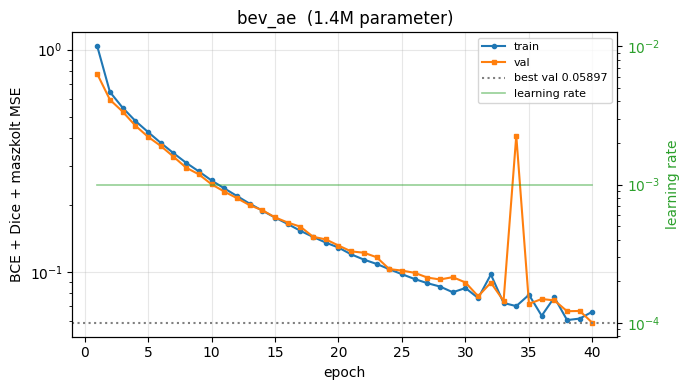

In [9]:
x_train, x_val = load_clouds(("train", "val"))
print(f"train {tuple(x_train.shape)}  val {tuple(x_val.shape)}  "
      f"{(x_train.numel() + x_val.numel()) * 4 / 1e9:.1f} GB")
model = BEVConvAE()
hist_bev_ae, model = train_model(
    model, label="bev_ae", batch=BATCH["bev_ae"],
    train_data=x_train, val_data=x_val, epochs=EPOCHS, lr=1e-3,
    clip=1.0)
plot_history(hist_bev_ae, ylabel="BCE + Dice + maszkolt MSE")

In [10]:
free_vram(model)
print("bev_ae utan:", vram())
print("(a pontfelhok a RAM-ban maradnak - a point_mae is azokat hasznalja)")

bev_ae utan: 0.00 GB foglalt / 0.00 GB fenntartva / 16.7 GB osszes
(a pontfelhok a RAM-ban maradnak - a point_mae is azokat hasznalja)


## 5. `graph_ae` — range image + dinamikus graf

train:   0%|          | 0/35037 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

ranges  train (35037, 1, 44, 256)  val (7507, 1, 44, 256)  1.9 GB
graph_ae: FOLYTATAS a 32. epoch utan (best val 0.02050)
graph_ae  (2.1M parameter, lr=4.5e-06, batch=32, 35037 train frame, epoch 33-40)


epoch 33/40:   0%|          | 0/1095 [00:00<?, ?it/s]

  epoch 33  train 0.03770  val 0.03734   l1_occupied 0.020  l1_empty 0.725  lr 4.50e-06  [2 perc]  *


...

  epoch 38  train 0.03682  val 0.03642   l1_occupied 0.020  l1_empty 0.722  lr 4.50e-06  [11 perc]  *


epoch 39/40:   0%|          | 0/1095 [00:00<?, ?it/s]

  epoch 39  train 0.03666  val 0.03650   l1_occupied 0.020  l1_empty 0.721  lr 4.50e-06  [13 perc]


epoch 40/40:   0%|          | 0/1095 [00:00<?, ?it/s]

  epoch 40  train 0.03646  val 0.03632   l1_occupied 0.020  l1_empty 0.711  lr 4.50e-06  [15 perc]
  kesz: lidar/graph_ae.ckpt  (best val 0.01953, 14.9 perc ebben a futasban)


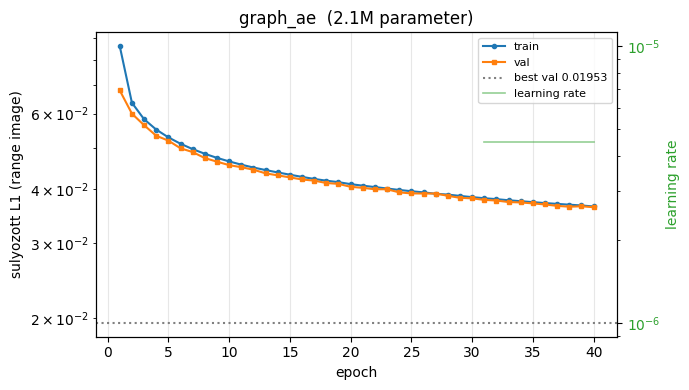

In [11]:
# A pontfelhoket eldobjuk, hogy a range image-eknek legyen helye.
drop("x_train", "x_val")
r_train, r_val = load_ranges(("train", "val"))
print(f"ranges  train {tuple(r_train.shape)}  val {tuple(r_val.shape)}  "
      f"{(r_train.numel() + r_val.numel()) * 4 / 1e9:.1f} GB")
GRAPH_LR = 4.5e-6

model = LidarAE(DDCONFIG)
hist_graph_ae, model = train_model(
    model, label="graph_ae", batch=BATCH["graph_ae"],
    train_data=r_train, val_data=r_val, epochs=EPOCHS, lr=GRAPH_LR)
plot_history(hist_graph_ae, ylabel="sulyozott L1 (range image)")


In [12]:
free_vram(model)
print("graph_ae utan:", vram())

graph_ae utan: 0.01 GB foglalt / 0.02 GB fenntartva / 16.7 GB osszes


## 6. `point_mae` — maszkolt autoencoder

train:   0%|          | 0/35037 [00:00<?, ?frame/s]

val  :   0%|          | 0/7507 [00:00<?, ?frame/s]

point_mae  (4.0M parameter, lr=0.002, batch=40, 35037 train frame, epoch 1-40)


epoch 1/40:   0%|          | 0/876 [00:00<?, ?it/s]

  epoch  1  train 1.75824  val 1.09344   spread_ratio 0.369  cd_m2 1.697  gain_pct 85.227  lr 2.00e-03  [4 perc]  *


...

  epoch 38  train 0.53661  val 0.54178   spread_ratio 0.418  cd_m2 0.849  gain_pct 92.688  lr 3.22e-05  [153 perc]


epoch 39/40:   0%|          | 0/876 [00:00<?, ?it/s]

  epoch 39  train 0.53610  val 0.54041   spread_ratio 0.418  cd_m2 0.849  gain_pct 92.703  lr 2.31e-05  [157 perc]  *


epoch 40/40:   0%|          | 0/876 [00:00<?, ?it/s]

  epoch 40  train 0.53543  val 0.54018   spread_ratio 0.419  cd_m2 0.848  gain_pct 92.707  lr 2.00e-05  [161 perc]  *
  kesz: lidar/point_mae.ckpt  (best val 0.54018, 161.5 perc ebben a futasban)


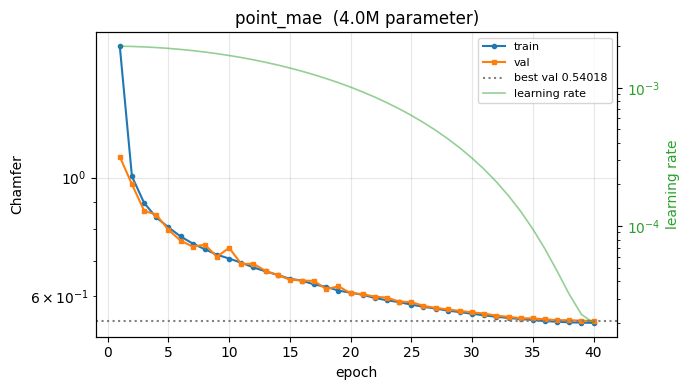

In [13]:
drop("r_train", "r_val")
if "x_train" not in globals():
    x_train, x_val = load_clouds(("train", "val"))

model = PointMAE(num_group=512)
hist_point_mae, model = train_model(
    model, label="point_mae", batch=40,
    train_data=x_train, val_data=x_val, epochs=EPOCHS, lr=2e-3,
    sched="cosine", resume=True,        
    warmup_frac=0.05)
plot_history(hist_point_mae, ylabel="Chamfer")


In [14]:
free_vram(model)
print("point_mae utan:", vram())

point_mae utan: 0.02 GB foglalt / 2.03 GB fenntartva / 16.7 GB osszes


 # Modell osszehasonlitas


 3 db data sample kivalasztasa es megnezese

In [15]:

SHOW_IDX = [len(PATHS) // 6, len(PATHS) // 2, 5 * len(PATHS) // 6]

show_raw = [np.load(PATHS[i]) for i in SHOW_IDX]
show_pts = torch.stack([
    torch.from_numpy(a[np.random.default_rng(i).choice(
        len(a), N_POINTS, replace=len(a) < N_POINTS)].astype(np.float32))
    for i, a in zip(SHOW_IDX, show_raw)])
show_ri = torch.from_numpy(np.stack([points_to_range_image(a) for a in show_raw]))

for i, a in zip(SHOW_IDX, show_raw):
    print(f"frame {i:6d}   {len(a):6d} nyers pont   "
          f"x {a[:, 0].min():6.1f}..{a[:, 0].max():5.1f}   "
          f"z {a[:, 2].min():5.1f}..{a[:, 2].max():5.1f}")

print(f"\nmintavetelve  {tuple(show_pts.shape)}   range image {tuple(show_ri.shape)}")


frame   8341    31572 nyers pont   x  -49.1.. 49.2   z  -2.7..  8.7
frame  25025    28370 nyers pont   x  -49.5.. 49.5   z  -2.4..  7.7
frame  41709    33490 nyers pont   x  -49.9.. 49.8   z  -2.7..  8.7

mintavetelve  (3, 24576, 3)   range image (3, 1, 44, 256)


In [16]:
from plotly.subplots import make_subplots


def show_frame(pts, rec=None, label="", max3d=12000, bad_thr=1.0):
    pts = pts.cpu().numpy() if hasattr(pts, "cpu") else np.asarray(pts)

    def thin(a, n, seed=0):
        if len(a) <= n:
            return a
        return a[np.random.default_rng(seed).choice(len(a), n, replace=False)]

    # --- egyetlen felho, nincs mit osszevetni -----------------------------
    if rec is None:
        main = thin(pts, max3d, 0)
        fig = go.Figure([
            go.Scatter3d(
                x=main[:, 0], y=main[:, 1], z=main[:, 2], mode="markers",
                marker=dict(size=1.6, color=main[:, 2], colorscale="Viridis",
                            cmin=-3, cmax=4, opacity=0.85,
                            colorbar=dict(title="z [m]", thickness=12, len=0.6)),
                name=f"pontfelho ({len(pts)})",
                hovertemplate="x %{x:.1f}<br>y %{y:.1f}<br>z %{z:.1f}<extra></extra>"),
            go.Scatter3d(x=[0], y=[0], z=[0], mode="markers",
                         marker=dict(size=6, color="#00cc44", symbol="diamond"),
                         name="ego (lidar)", hoverinfo="name")])
        fig.update_layout(
            title=label or "pontfelho", height=620,
            margin=dict(l=0, r=0, t=40, b=0), legend=dict(x=0, y=1),
            scene=dict(aspectmode="data", xaxis_title="x [m]  (elore)",
                       yaxis_title="y [m]  (balra)", zaxis_title="z [m]  (fel)",
                       camera=dict(eye=dict(x=-1.4, y=-1.4, z=0.9))))
        fig.show()
        return

    rec = rec.cpu().numpy() if hasattr(rec, "cpu") else np.asarray(rec)

    # --- a hiba: rekonstrualt pont -> legkozelebbi valodi -----------------
    rec_t = thin(rec, max3d, 0)
    a = torch.from_numpy(np.ascontiguousarray(rec_t)).float().to(DEVICE)
    b = torch.from_numpy(np.ascontiguousarray(pts)).float().to(DEVICE)
    err = np.concatenate([
        torch.cdist(a[i:i + 4096], b).min(dim=1)[0].cpu().numpy()
        for i in range(0, len(a), 4096)])
    del a, b
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    bad = err >= bad_thr
    ref = thin(pts, max3d, 1)

    fig = make_subplots(
        rows=1, cols=2, specs=[[{"type": "scene"}, {"type": "scene"}]],
        subplot_titles=(f"EREDETI — {len(pts)} pont",
                        f"REKONSTRUKCIO — {len(rec)} pont   "
                        f"(median hiba {np.median(err):.3f} m, "
                        f"hibas {100 * bad.mean():.1f}%)"),
        horizontal_spacing=0.02)

    # BAL: az eredeti, magassag szerint. Ugyanaz a skala, mint mindenhol.
    fig.add_trace(go.Scatter3d(
        x=ref[:, 0], y=ref[:, 1], z=ref[:, 2], mode="markers",
        marker=dict(size=1.5, color=ref[:, 2], colorscale="Viridis",
                    cmin=-3, cmax=4, opacity=0.85),
        name="eredeti",
        hovertemplate="x %{x:.1f}<br>y %{y:.1f}<br>z %{z:.1f}<extra></extra>"),
        row=1, col=1)

    # JOBB: a rekonstrukcio. Piros = a helyen, citromsarga = odanemvalo.
    ok = rec_t[~bad]
    fig.add_trace(go.Scatter3d(
        x=ok[:, 0], y=ok[:, 1], z=ok[:, 2], mode="markers",
        marker=dict(size=1.8, color="#dd2222", opacity=0.85),
        name=f"a helyen ({len(ok)})", customdata=err[~bad],
        hovertemplate="hiba %{customdata:.2f} m<extra></extra>"),
        row=1, col=2)

    hib = rec_t[bad]
    fig.add_trace(go.Scatter3d(
        x=hib[:, 0], y=hib[:, 1], z=hib[:, 2], mode="markers",
        marker=dict(size=3.2, color="#eeee22", opacity=1.0,
                    line=dict(width=0.5, color="#886600")),
        name=f"hibas &gt; {bad_thr:g} m ({len(hib)})", customdata=err[bad],
        hovertemplate="hiba %{customdata:.2f} m<extra></extra>"),
        row=1, col=2)

    # Az ego mindket panelen, hogy legyen kozos fogodzo.
    for col in (1, 2):
        fig.add_trace(go.Scatter3d(
            x=[0], y=[0], z=[0], mode="markers",
            marker=dict(size=6, color="#00cc44", symbol="diamond"),
            name="ego", showlegend=(col == 1), hoverinfo="name"),
            row=1, col=col)

    # A LENYEG: a ket scene kozos kameran van. A "scene2.camera" a
    # "scene"-re hivatkozik, igy a plotly egyutt forgatja oket - enelkul
    # ket kulon nezopontbol latnad a ket felhot, es nem lehetne osszevetni.
    axis_titles = dict(xaxis_title="x [m]", yaxis_title="y [m]",
                       zaxis_title="z [m]")
    cam = dict(eye=dict(x=-1.4, y=-1.4, z=0.9))
    fig.update_layout(
        title=label, height=660, margin=dict(l=0, r=0, t=70, b=0),
        legend=dict(x=0, y=1),
        scene=dict(aspectmode="data", camera=cam, **axis_titles),
        scene2=dict(aspectmode="data", camera=cam, **axis_titles))

    # A kamerak osszekotese: a plotly-ban ez a "scene.camera" esemenyen
    # keresztul megy, amit a notebookban a `uirevision` tart szinkronban.
    fig.update_layout(uirevision="sync")
    fig.show()


# --- a harom minta ---------------------------------------------------------
for row, (idx, pts) in enumerate(zip(SHOW_IDX, show_pts)):
    where = ["eleje", "kozepe", "vege"][row]
    show_frame(pts, label=f"frame {idx} ({where}) — nyers pontfelho")


# Minta elemek rekonstrukciója és vizsgálata

Eloszor chamfer distnace 

In [17]:
ARCHS = {"BEVConvAE": BEVConvAE, "LidarAE": LidarAE, "PointMAE": PointMAE}
LABELS = ["bev_ae", "graph_ae", "point_mae"]


def load_model(label, device=DEVICE):
    ck = torch.load(f"lidar/{label}.ckpt", map_location="cpu", weights_only=False)
    hp = dict(ck.get("hparams") or {})

    if ck["arch"] == "LidarAE":
        model = LidarAE(DDCONFIG, **hp)      # nem Lightning, kell a DDCONFIG
    else:
        model = ARCHS[ck["arch"]](**hp)

    model.load_state_dict(ck.get("best_state") or ck["state_dict"])
    return model.eval().to(device), ck


for lbl in LABELS:
    m, ck = load_model(lbl, device="cpu")
    print(f"{lbl:10s}  {sum(p.numel() for p in m.parameters()) / 1e6:5.1f}M "
          f"parameter   {ck['epoch']:3d} epoch   best val {ck['best_val']:.5f}")
    free_vram(m)


bev_ae        1.4M parameter    40 epoch   best val 0.05897
graph_ae      2.1M parameter    40 epoch   best val 0.01953
point_mae     4.0M parameter    40 epoch   best val 0.54018


In [18]:
RECON = {lbl: [] for lbl in LABELS}

# 1. bev_ae: a BEV racs vissza pontokka ------------------------------------
model, _ = load_model("bev_ae")
for f in range(len(SHOW_IDX)):
    with torch.no_grad():
        bev = model(show_pts[f].unsqueeze(0).to(DEVICE))[0].cpu().numpy()
    occ, zmax_c, zmin_c = bev                    # [occupancy, z_max, z_min]

    # Ahol az occupancy 0.5 folott van, oda pont kerul - a cella KOZEPEBE
    # (+0.5, mert a to_bev floor-ral indexelt).
    rows, cols = np.nonzero(occ > 0.5)
    v = model.hparams.voxel_size
    x_min, y_min, z_lo, _, _, z_hi = model.pc_range
    x, y = x_min + (cols + 0.5) * v, y_min + (rows + 0.5) * v

    # Cellankent KET pont: z_max es z_min. Igy a fuggoleges kiterjedes is
    # megmarad (falnal a ketto messze, uttestnel egybeesik). A visszaskalazas
    # a to_bev keplet inverze:  z_norm = 0.05 + 0.95 * c
    parts = [np.stack([x, y, z_lo + np.clip((ch[rows, cols] - 0.05) / 0.95,
                                            0, 1) * (z_hi - z_lo)], -1)
             for ch in (zmax_c, zmin_c)]
    RECON["bev_ae"].append(np.concatenate(parts).astype(np.float32))
free_vram(model)

# 2. graph_ae: range image -> inverz gombi projekcio -----------------------
model, _ = load_model("graph_ae")
SIZE, FOV, DEPTH_SCALE = (44, 256), (-0.9, -25.0), 5.68   # = points_to_range_image
RECON_RI = []

for f in range(len(SHOW_IDX)):
    with torch.no_grad():
        ri = model(show_ri[f].unsqueeze(0).to(DEVICE))[0].cpu().numpy().squeeze()
    RECON_RI.append(ri)

    # Normalizalas visszafele: [-1,1] -> [0,1] -> *scale -> 2^d - 1 -> meter
    d = np.clip((ri + 1.0) / 2.0 * DEPTH_SCALE, 0.0, None)
    depth = np.power(2.0, d) - 1.0 - 0.0001

    rr, cc = np.nonzero(ri > -0.999)             # csak a NEM ures cellak
    r = depth[rr, cc]
    fov_up, fov_down = FOV[0] / 180.0 * np.pi, FOV[1] / 180.0 * np.pi
    fov_range = abs(fov_down) + abs(fov_up)

    # A pcd2range inverze. A minusz azert jon vissza, mert a vetitesnel
    # yaw = -atan2(y, x) volt; a +0.5 a cella kozepe.
    yaw = -(((cc + 0.5) / SIZE[1]) * 2.0 - 1.0) * np.pi
    pitch = (1.0 - (rr + 0.5) / SIZE[0]) * fov_range - abs(fov_down)

    RECON["graph_ae"].append(np.stack([r * np.cos(pitch) * np.cos(yaw),
                                       r * np.cos(pitch) * np.sin(yaw),
                                       r * np.sin(pitch)], -1).astype(np.float32))
free_vram(model)

# 3. point_mae: josolt patch-ek + a lathato patch-ek -----------------------
model, _ = load_model("point_mae")
RECON_PRED = []                      # CSAK a josolt resz

for f in range(len(SHOW_IDX)):
    xb = show_pts[f].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        # A forward maga maszkol: rebuild = joslat a maszkolt patch-ekre.
        rebuild, gt, mask, center = model(xb)
        mc = model.denorm_centers(center[mask].reshape(1, -1, 3))
        pred = (model.denorm_patches(rebuild)
                + mc.unsqueeze(2)).reshape(-1, 3).cpu().numpy()

        # A LATHATO patch-ek eredeti pontjai. Ezeket a modell bemenetkent
        # kapta - de a masik ket modell a TELJES felhot rekonstrualja,
        # ezert nelkuluk a point_mae szandekosan hianyosan indulna.
        patches, ctr = model.group(xb)
        vis = (model.denorm_patches(patches[~mask])
               + model.denorm_centers(ctr[~mask]).unsqueeze(1))
        vis = vis.reshape(-1, 3).cpu().numpy()

    RECON_PRED.append(pred.astype(np.float32))
    RECON["point_mae"].append(np.concatenate([pred, vis]).astype(np.float32))
free_vram(model)

for lbl in LABELS:
    print(f"{lbl:12s} " + "  ".join(f"{len(p):6d} pont" for p in RECON[lbl]))
print(f"{'eredeti':12s} " + "  ".join(f"{N_POINTS:6d} pont" for _ in SHOW_IDX))


bev_ae         5862 pont    4354 pont    6004 pont
graph_ae      11060 pont   10846 pont   11190 pont
point_mae     16384 pont   16384 pont   16384 pont
eredeti       24576 pont   24576 pont   24576 pont


In [19]:
print(f"{'modell':12s} {'frame':>8s} {'elvesztett':>11s} {'kitalalt':>10s} "
      f"{'chamfer':>9s} {'pont':>7s}")
print("-" * 62)

for lbl in LABELS:
    for f, idx in enumerate(SHOW_IDX):
        ref = show_pts[f].to(dev := DEVICE)
        rec = torch.from_numpy(RECON[lbl][f]).float().to(dev)

        # Darabolva, kulonben a 24576 x 11000-es tavolsagmatrix megeszi a VRAM-ot.
        fwd = []
        for i in range(0, len(ref), 4096):
            fwd.append(torch.cdist(ref[i:i + 4096], rec).min(dim=1)[0])
        fwd = torch.cat(fwd)

        bwd = []
        for i in range(0, len(rec), 4096):
            bwd.append(torch.cdist(rec[i:i + 4096], ref).min(dim=1)[0])
        bwd = torch.cat(bwd)

        lost, made = float(fwd.mean()), float(bwd.mean())
        print(f"{lbl:12s} {idx:8d} {lost:10.3f}m {made:9.3f}m "
              f"{lost + made:8.3f}m {len(rec):7d}")

        del ref, rec, fwd, bwd
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    print()

print("""  elvesztett : a valodi jelenetbol mennyi NEM kapott rekonstrualt pontot.
               Ez a veszelyes: az RL nem latna egy ott levo akadalyt.
  kitalalt   : a rekonstrualt pontok mennyire vannak valodi feluleten.
               Ha nagy, a modell nem letezo akadalyt rajzol.
  chamfer    : a ketto osszege, meterben.""")


modell          frame  elvesztett   kitalalt   chamfer    pont
--------------------------------------------------------------
bev_ae           8341      0.521m     0.454m    0.975m    5862
bev_ae          25025      0.394m     0.293m    0.687m    4354
bev_ae          41709      0.443m     0.410m    0.852m    6004

graph_ae         8341      0.943m     0.401m    1.344m   11060
graph_ae        25025      0.418m     0.310m    0.728m   10846
graph_ae        41709      1.057m     0.199m    1.257m   11190

point_mae        8341      0.706m     0.184m    0.890m   16384
point_mae       25025      0.473m     0.103m    0.576m   16384
point_mae       41709      0.738m     0.177m    0.914m   16384

  elvesztett : a valodi jelenetbol mennyi NEM kapott rekonstrualt pontot.
               Ez a veszelyes: az RL nem latna egy ott levo akadalyt.
  kitalalt   : a rekonstrualt pontok mennyire vannak valodi feluleten.
               Ha nagy, a modell nem letezo akadalyt rajzol.
  chamfer    : a ketto ossze

## BEV osszehasonlitas  a pontfelhoknek

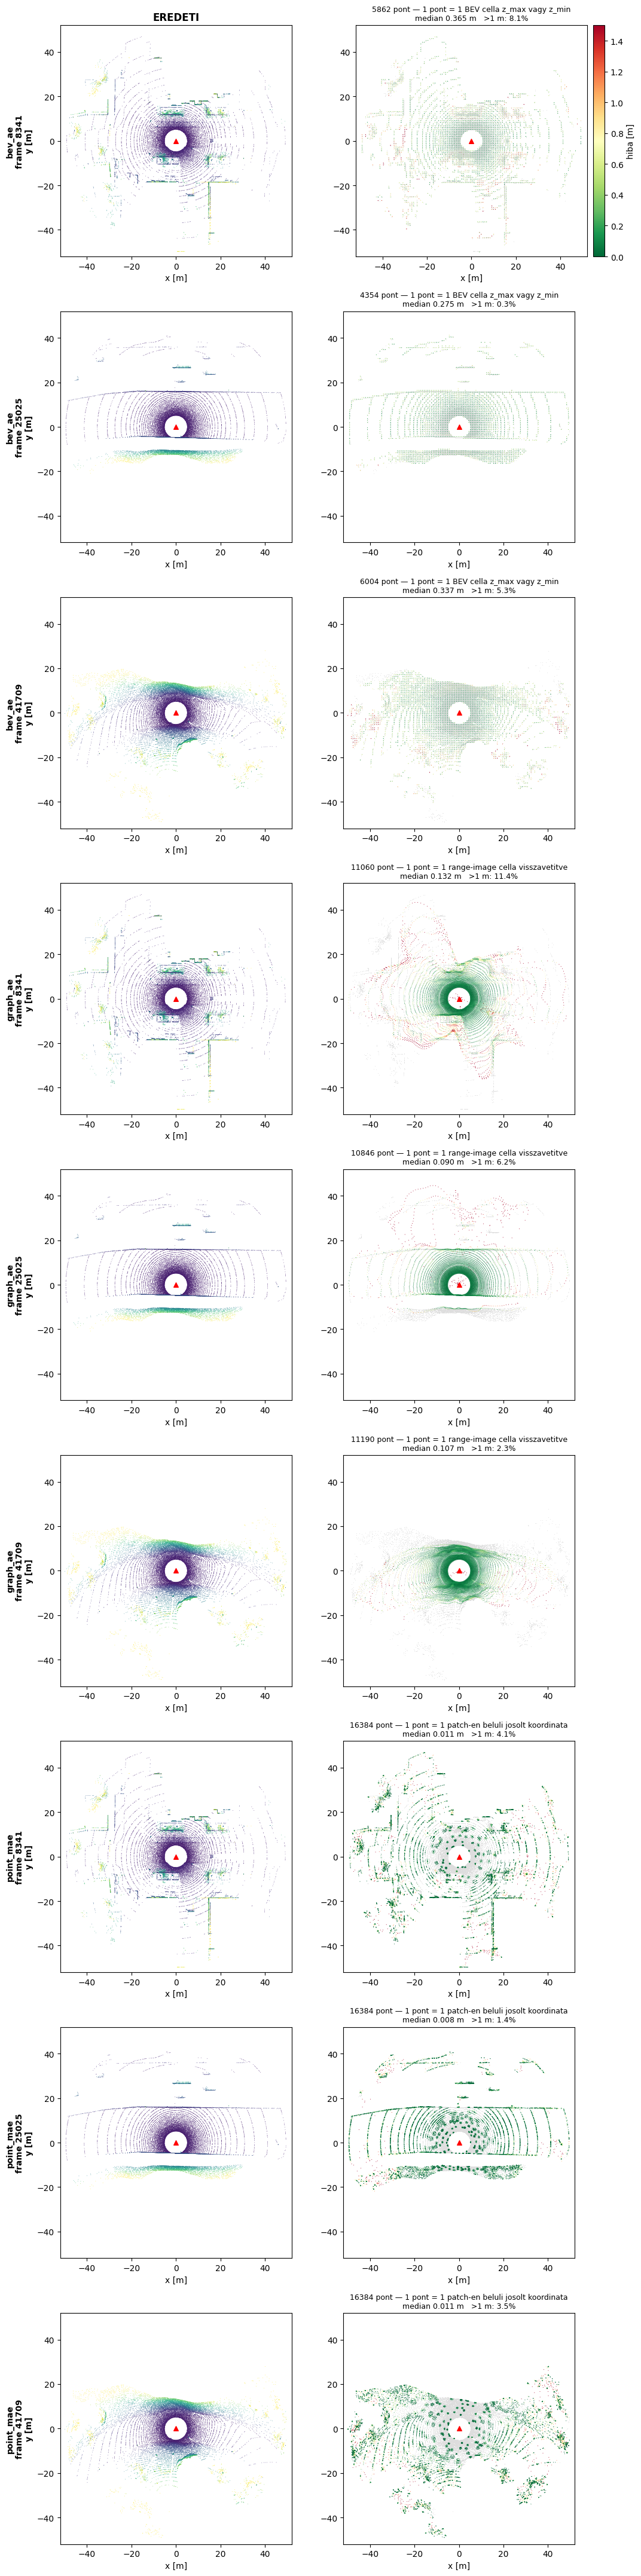

In [20]:
# --- BEV parok: eredeti | rekonstrukcio a hibajaval -----------------------
# Jobb oldalt minden rekonstrualt pont a HIBAJA szerint szinezve (tavolsag
# a legkozelebbi valodi ponttol), az eredeti halvany szurken ala:
#   zold  (< 0.3 m)  eltalalta      sarga (0.3-1 m)  elmosodott
#   piros (> 1 m)    odanemvalo pont - az RL ott akadalyt latna
# Ahol SZURKE latszik szines pont nelkul: azt a reszt a modell elvesztette.

WHAT = {"bev_ae": "1 pont = 1 BEV cella z_max vagy z_min",
        "graph_ae": "1 pont = 1 range-image cella visszavetitve",
        "point_mae": "1 pont = 1 patch-en beluli josolt koordinata"}

fig, axes = plt.subplots(len(LABELS) * len(SHOW_IDX), 2, figsize=(11, 4.8 * 9))

row = 0
for lbl in LABELS:
    for f, idx in enumerate(SHOW_IDX):
        ref = show_pts[f].numpy()
        rec = RECON[lbl][f]

        # A hiba: minden rekonstrualt pont -> legkozelebbi valodi.
        # Darabolva, kulonben a tavolsagmatrix megeszi a VRAM-ot.
        a = torch.from_numpy(rec).float().to(DEVICE)
        b = show_pts[f].to(DEVICE)
        err = torch.cat([torch.cdist(a[i:i + 4096], b).min(dim=1)[0]
                         for i in range(0, len(a), 4096)]).cpu().numpy()
        del a, b
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # 1. eredeti - a szin a MAGASSAG (lapos uttest sotet, epulet vilagos)
        ax = axes[row, 0]
        ax.scatter(ref[:, 0], ref[:, 1], c=ref[:, 2], s=0.3, cmap="viridis",
                   vmin=-3, vmax=4, linewidths=0)
        ax.set_ylabel(f"{lbl}\nframe {idx}\ny [m]", fontsize=10,
                      fontweight="bold")
        ax.set_title("EREDETI" if row == 0 else "", fontsize=12,
                     fontweight="bold")

        # 2. rekonstrukcio, a hibaval szinezve
        ax = axes[row, 1]
        ax.scatter(ref[:, 0], ref[:, 1], c="#dddddd", s=0.3, linewidths=0)
        sc = ax.scatter(rec[:, 0], rec[:, 1], c=err, s=0.5, cmap="RdYlGn_r",
                        vmin=0, vmax=1.5, linewidths=0)
        ax.set_title(f"{len(rec)} pont — {WHAT[lbl]}\n"
                     f"median {np.median(err):.3f} m   "
                     f">1 m: {100 * (err > 1).mean():.1f}%", fontsize=9)
        if row == 0:
            plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02,
                         label="hiba [m]")

        for ax in axes[row]:
            ax.scatter([0], [0], c="red", s=30, marker="^")   # ego
            ax.set_xlim(-52, 52)
            ax.set_ylim(-52, 52)
            ax.set_aspect("equal")
            ax.set_xlabel("x [m]")
        row += 1

plt.tight_layout()
plt.show()


## Osszehasonlitas 3D terben is az egse modelleket 

In [21]:
for lbl in LABELS:
    for f, idx in enumerate(SHOW_IDX):
        where = ["eleje", "kozepe", "vege"][f]
        show_frame(show_pts[f], rec=RECON[lbl][f], max3d=10000,
                   label=f"{lbl} — frame {idx} ({where})")


# Latens minoseg analizis 

In [22]:
N_LAT = 300          # ennyi EGYMAST KOVETO frame - az idobeli simasag miatt
LAT_START = len(PATHS) // 2          # a felvetel kozeperol

lat_paths = PATHS[LAT_START:LAT_START + N_LAT]
print(f"{len(lat_paths)} egymast koveto frame a {LAT_START}. indextol\n")

# A nyers felhok es a range image-ek egyszer, elore - hogy a harom modell
# UGYANAZT az adatot lassa.
lat_pts = torch.stack([
    torch.from_numpy(np.load(p)[np.random.default_rng(i).choice(
        len(np.load(p)), N_POINTS,
        replace=len(np.load(p)) < N_POINTS)].astype(np.float32))
    for i, p in enumerate(tqdm(lat_paths, desc="pontfelhok"))])
lat_ri = torch.from_numpy(np.stack([
    points_to_range_image(np.load(p))
    for p in tqdm(lat_paths, desc="range imagek")]))

LATENT = {}

for lbl in LABELS:
    model, _ = load_model(lbl)
    data = lat_ri if lbl == "graph_ae" else lat_pts
    batch = 16 if lbl == "point_mae" else 64

    zs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(data), batch), desc=f"{lbl:10s}", leave=False):
            xb = data[i:i + batch].to(DEVICE).float()
            z = model.encode(xb)
            zs.append(z.reshape(len(xb), -1).cpu())     # lapitas
    LATENT[lbl] = torch.cat(zs).numpy()
    free_vram(model)

    z = LATENT[lbl]
    print(f"{lbl:10s} latens {z.shape}   "
          f"szoras {z.std():.4f}   "
          f"halott dim {100 * (z.std(0) < 1e-4).mean():.1f}%")


300 egymast koveto frame a 25025. indextol



pontfelhok:   0%|          | 0/300 [00:00<?, ?it/s]

range imagek:   0%|          | 0/300 [00:00<?, ?it/s]

bev_ae    :   0%|          | 0/5 [00:00<?, ?it/s]

bev_ae     latens (300, 16384)   szoras 0.6181   halott dim 0.0%


graph_ae  :   0%|          | 0/5 [00:00<?, ?it/s]

graph_ae   latens (300, 5632)   szoras 0.6605   halott dim 0.0%


point_mae :   0%|          | 0/19 [00:00<?, ?it/s]

[W922 16:31:11.394743691 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 13692305408 bytes (free: 13702922240, total: 16712925184).
[W922 16:31:11.394953441 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 13692305408 bytes (free: 13702922240, total: 16712925184).


point_mae  latens (300, 98304)   szoras 0.6486   halott dim 0.0%


In [23]:
# --- 1. EFFEKTIV RANG (RankMe) --------------------------------------------
# A "halott dimenzio" a leggyengebb teszt: csak a TELJESEN allando
# dimenziokat fogja meg. A valodi kollapszus finomabb - a dimenziok
# mozognak, de mind UGYANAZT mozogjak (eros korrelacio), igy a 16384
# dimenzio effektiven 12-t er.
#
# A RankMe (Garrido et al., 2023) a szingularis ertekek ENTROPIAJABOL
# szamol rangot:  p_i = s_i / sum(s),  rank = exp(-sum(p_i * log p_i))
# Ha minden dimenzio egyforman fontos, ez = a dimenziok szama.
# Ha egy dimenzio visz mindent, ez = 1.

print(f"{'modell':10s} {'dim':>7s} {'RankMe':>9s} {'rang %':>8s} "
      f"{'99% var':>9s} {'top1 var':>9s}")
print("-" * 56)

RANK = {}
for lbl in LABELS:
    z = LATENT[lbl].astype(np.float64)
    z = z - z.mean(0)                      # centralas: a RankMe szorast mer

    # Csak a szingularis ertekek kellenek, a vektorok nem.
    s = np.linalg.svd(z, compute_uv=False)

    p = s / s.sum()
    p = p[p > 1e-12]
    rankme = float(np.exp(-(p * np.log(p)).sum()))

    # Hany komponens kell a variancia 99%-ahoz. Ez a hagyomanyos PCA-mercen
    # ugyanazt mutatja, csak durvabban.
    var = s ** 2
    cum = np.cumsum(var) / var.sum()
    n99 = int(np.searchsorted(cum, 0.99) + 1)

    RANK[lbl] = dict(rankme=rankme, n99=n99, s=s, dim=z.shape[1])
    print(f"{lbl:10s} {z.shape[1]:7d} {rankme:9.1f} "
          f"{100 * rankme / z.shape[1]:7.1f}% {n99:9d} "
          f"{100 * var[0] / var.sum():8.1f}%")

print("""
  RankMe   : effektiv dimenzioszam. MINEL NAGYOBB, annal tobb fuggetlen
             informaciot hordoz a latens.
  rang %   : a RankMe a nevleges dimenziok szazalekaban. Ez a TISZTESSEGES
             osszevetes, mert a harom latens merete nagyon kulonbozik.
  99% var  : hany fokomponens kell a variancia 99%-ahoz.
  top1 var : mennyit visz az ELSO fokomponens. Ha 50% folott, a latens
             nagy resze egyetlen iranyban mozog - ez kollapszus-gyanu.""")


modell         dim    RankMe   rang %   99% var  top1 var
--------------------------------------------------------
bev_ae       16384     237.7     1.5%       268     18.6%
graph_ae      5632     181.4     3.2%       218     31.6%
point_mae    98304     295.9     0.3%       295      2.8%

  RankMe   : effektiv dimenzioszam. MINEL NAGYOBB, annal tobb fuggetlen
             informaciot hordoz a latens.
  rang %   : a RankMe a nevleges dimenziok szazalekaban. Ez a TISZTESSEGES
             osszevetes, mert a harom latens merete nagyon kulonbozik.
  99% var  : hany fokomponens kell a variancia 99%-ahoz.
  top1 var : mennyit visz az ELSO fokomponens. Ha 50% folott, a latens
             nagy resze egyetlen iranyban mozog - ez kollapszus-gyanu.


In [24]:
# --- 2. k-NN KONZISZTENCIA + 3. IDOBELI SIMASAG ---------------------------
# 2. Ha a latens ertelmes metrikat tanult, akkor a latens-terben kozeli
#    framek FIZIKAILAG is hasonloak. Ezt ugy merjuk, hogy a latens-szomszedok
#    Chamfer-tavolsagat osszevetjuk a veletlen parokeval.
#
# 3. A framek IDORENDBEN keszultek: az n es n+1 frame fizikailag kozel van.
#    Egy jo latens ezt tukrozze. Ha a szomszedos framek latense ugyanolyan
#    tavol van, mint a veletlen pare, a latens ZAJOS - az RL nem tud ra
#    politikat epiteni.

K = 5                        # hany legkozelebbi szomszedot nezunk
STRIDE, CHUNK = 16, 24       # 1536 pont/frame, 24 par egyszerre

# A FIZIKAI tavolsagmatrix egyszer, minden modellre kozosen: Chamfer
# mindenkivel mindenkit.
#
# VRAM: a naiv verzio (minden j egyszerre) 300 x 3072 x 3072 float =
# 11 GB-ot kerne EGYETLEN sorra. Ezert a belso ciklus is darabolva megy,
# es a felhoket jobban ritkitjuk. A rangsorhoz 1536 pont bosegesen eleg -
# nem a Chamfer abszolut erteke erdekel, hanem hogy melyik frame van
# kozelebb melyikhez.

free_vram()
sub = lat_pts[:, ::STRIDE].contiguous()          # CPU-n marad
n = len(sub)
phys_np = np.zeros((n, n), dtype=np.float32)

with torch.no_grad():
    for i in tqdm(range(n), desc="fizikai tavolsagok"):
        a = sub[i].to(DEVICE)                    # (P, 3)
        for j0 in range(0, n, CHUNK):
            b = sub[j0:j0 + CHUNK].to(DEVICE)    # (C, P, 3)
            d = torch.cdist(a.unsqueeze(0).expand(len(b), -1, -1), b)
            phys_np[i, j0:j0 + len(b)] = (
                d.min(dim=2)[0].mean(dim=1)
                + d.min(dim=1)[0].mean(dim=1)).cpu().numpy()
            del b, d
        del a
if torch.cuda.is_available():
    torch.cuda.empty_cache()

np.fill_diagonal(phys_np, np.inf)
rand_phys = float(phys_np[np.isfinite(phys_np)].mean())

print(f"\natlagos fizikai (Chamfer) tavolsag veletlen par kozt: "
      f"{rand_phys:.3f}\n")
print(f"{'modell':10s} {'kNN fizikai':>12s} {'vs veletlen':>12s} "
      f"{'idobeli':>9s} {'vs veletlen':>12s}")
print("-" * 60)

for lbl in LABELS:
    z = LATENT[lbl]
    zt = torch.from_numpy(z).float()
    # Normalas: koszinusz-tavolsagot akarunk, nem euklideszit. Kulonben a
    # nagyobb NORMAJU latens automatikusan "tavolabbinak" tunne.
    zt = zt / zt.norm(dim=1, keepdim=True).clamp(min=1e-8)

    dz = torch.cdist(zt, zt).numpy()
    np.fill_diagonal(dz, np.inf)

    # 2. k-NN: a latens-szomszedok FIZIKAI tavolsaga. Ha a latens jo, ez
    #    jelentosen kisebb, mint a veletlen pare.
    nn = np.argsort(dz, axis=1)[:, :K]
    knn_phys = float(np.mean([phys_np[i, nn[i]].mean() for i in range(len(z))]))

    # 3. Idobeli: a SZOMSZEDOS framek latens-tavolsaga vs a veletlen pare.
    consec = float(np.mean([dz[i, i + 1] for i in range(len(z) - 1)]))
    rand_lat = float(dz[np.isfinite(dz)].mean())

    print(f"{lbl:10s} {knn_phys:12.3f} {knn_phys / rand_phys:11.2f}x "
          f"{consec:9.3f} {consec / rand_lat:11.2f}x")

print("""
  kNN fizikai : a latens-terben legkozelebbi K frame atlagos FIZIKAI
                (Chamfer) tavolsaga. Minel kisebb, annal jobb.
  vs veletlen : ugyanez a veletlen par atlagahoz kepest. 1.00x = a latens
                SEMMIT nem tud (a szomszedai ugyanolyan tavoliak, mint
                barmelyik masik frame). Minel KISEBB, annal jobb.
  idobeli     : a szomszedos (n, n+1) framek latens-tavolsaga.
  vs veletlen : 1.00x = a latens ZAJOS, egy frame-nyi valtozasra akkorat
                ugrik, mint egy teljesen mas jelenetre. Minel KISEBB, annal
                simabb - DE a 0.00x fele kozelitve mar KOLLAPSZUS-gyanu
                (minden frame ugyanoda kepzodik). Ezert kell melle a
                RankMe: jo latens = magas rang ES alacsony idobeli arany.""")


fizikai tavolsagok:   0%|          | 0/300 [00:00<?, ?it/s]


atlagos fizikai (Chamfer) tavolsag veletlen par kozt: 3.294

modell      kNN fizikai  vs veletlen   idobeli  vs veletlen
------------------------------------------------------------
bev_ae            1.667        0.51x     0.480        0.60x
graph_ae          1.683        0.51x     0.323        0.42x
point_mae         2.637        0.80x     0.935        0.97x

  kNN fizikai : a latens-terben legkozelebbi K frame atlagos FIZIKAI
                (Chamfer) tavolsaga. Minel kisebb, annal jobb.
  vs veletlen : ugyanez a veletlen par atlagahoz kepest. 1.00x = a latens
                SEMMIT nem tud (a szomszedai ugyanolyan tavoliak, mint
                barmelyik masik frame). Minel KISEBB, annal jobb.
  idobeli     : a szomszedos (n, n+1) framek latens-tavolsaga.
  vs veletlen : 1.00x = a latens ZAJOS, egy frame-nyi valtozasra akkorat
                ugrik, mint egy teljesen mas jelenetre. Minel KISEBB, annal
                simabb - DE a 0.00x fele kozelitve mar KOLLAPSZUS-gyanu
         

# 9. Melyik modell kell az RL-nek? — linear probing

Az eddigi meresek KOZVETETTEK voltak. A rekonstrukcio (Chamfer) azt meri,
mennyire szep a visszaepitett felho; a RankMe es a k-NN azt, hogy a latens
nem kollapszalt-e. **Egyik sem arrol szol, amire az RL hasznalja.**

Ez a szakasz a self-supervised irodalom bevett mercejet futtatja le:
**linear probing** (SimCLR, MoCo, MAE, DINO mind ezt hasznalja).

**A logika.** Fagyaszd be az encodert, es tanits ra EGYETLEN linearis
reteget egy ismert feladatra. Ha a latens jo, egy linearis reteg is eleg -
mert az informacio mar *linearisan szeparalhato* formaban benne van. Egy
linearis reteg nem tud UJ informaciot eloallitani, csak kiolvasni.

**Miert epp ez szamit az RL-nek.** Az SB3 CNN feature-extractora es a PPO
policy/value feje nem sokkal tobb ennel: nehany konvolucio + linearis
retegek. Ha egy linearis probe nem tudja kiolvasni a latensbol, hol van
szabad ut, akkor a PPO-nak sem lesz konnyebb dolga.

**Ket celfeladat, szandekosan.**

| cel | mit mer | melyik modellnek "hazai palya" |
|---|---|---|
| BEV occupancy (32x32) | mely cellak foglaltak | **bev_ae** - ezt REKONSTRUALJA |
| szabad tavolsag 16 szektorban | meddig lehet menni az adott iranyban | egyiknek sem |

A masodik a lenyeg. A BEV occupancy ELFOGULT merce: a `bev_ae`-t pontosan
erre tanitottuk, tehat ott elonyben van. A szektoros szabad-tavolsag viszont
sem BEV-racs, sem range image, sem patch - MINDHAROM modellnek ujra kell
kodolnia. Es ez all a legkozelebb ahhoz, amire az RL-nek tenylegesen
szuksege van: "meddig mehetek erre?"


In [28]:
# --- Probe adat: minta a TELJES adathalmazbol -----------------------------
# 2000 frame kell. A 400-as probaval merve a probe TULILLESZTETT (a bev_ae a
# konstans baseline ALA ment), mert 256-399 dimenzios jellemzore 280 minta
# keves. 2000-nel a teszt-eredmeny mar stabil.

N_PROBE = 2000
POOL = 8            # a terbeli jellemzoterkep ennyiszer ennyire poolozva
PROBE_DIM = 256     # PCA-val MINDEN modell ennyi dimenziora - lasd lent

probe_idx = np.random.default_rng(0).choice(len(PATHS), N_PROBE, replace=False)
probe_raw = [np.load(PATHS[i]) for i in tqdm(probe_idx, desc="betoltes")]

probe_pts = torch.stack([
    torch.from_numpy(a[np.random.default_rng(int(i)).choice(
        len(a), N_POINTS, replace=len(a) < N_POINTS)].astype(np.float32))
    for i, a in zip(probe_idx, probe_raw)])
probe_ri = torch.from_numpy(np.stack([
    points_to_range_image(a) for a in tqdm(probe_raw, desc="range imagek")]))

print(f"{N_PROBE} frame   pontfelho {tuple(probe_pts.shape)}   "
      f"range image {tuple(probe_ri.shape)}")


betoltes:   0%|          | 0/2000 [00:00<?, ?it/s]

range imagek:   0%|          | 0/2000 [00:00<?, ?it/s]

2000 frame   pontfelho (2000, 24576, 3)   range image (2000, 1, 44, 256)


In [29]:
# --- CEL 1: BEV occupancy, 32x32-re durvitva ------------------------------
# A 128x128-as racs 16384 cimke framenkent - tul sok egy linearis
# regresszionak. A 4x4-es atlagolas 32x32 = 1024 cellara viszi le, es
# egyben zajt is szur (egyetlen pont miatt nem lesz foglalt egy cella).
#
# FIGYELEM: ez ELFOGULT merce. A bev_ae-t PONTOSAN erre tanitottuk, tehat
# itt hazai palyan jatszik. A CEL 2 a becsuletes osszevetes.

_p = BEVConvAE().eval()
with torch.no_grad():
    _occ = torch.cat([_p.to_bev(probe_pts[i:i + 32])[:, 0:1]
                      for i in tqdm(range(0, N_PROBE, 32), desc="BEV cel")])
    Y_OCC = (F.avg_pool2d(_occ, 4) > 0.0).float().reshape(N_PROBE, -1)
free_vram(_p)
print(f"cel 1: BEV occupancy {tuple(Y_OCC.shape)}   "
      f"foglalt cellak {100 * float(Y_OCC.mean()):.1f}%")


# --- CEL 2: szabad tavolsag 16 azimut-szektorban --------------------------
# "Meddig mehetek erre?" - 16 iranyban, meterben. Ez a SEMLEGES merce:
# sem BEV-racs, sem range image, sem patch, tehat mindharom modellnek
# ujra kell kodolnia. Es ez all a legkozelebb ahhoz, amit az RL hasznal.
#
# Csak az AKADALYMAGASSAGU pontok szamitanak (-2 .. +1 m a szenzorhoz
# kepest): a talaj es a fak koronaja nem akadaly. Az also 2. percentilis
# a "legkozelebbi akadaly", de zajturoen - egyetlen kiugro pont nem huzza le.

_free = []
for a in tqdm(probe_raw, desc="szabad tavolsag"):
    r = np.linalg.norm(a[:, :2], axis=1)
    th = np.arctan2(a[:, 1], a[:, 0])
    keep = (a[:, 2] > -2.0) & (a[:, 2] < 1.0) & (r > 1.0)
    sec = ((th[keep] + np.pi) / (2 * np.pi) * 16).astype(int).clip(0, 15)
    d = np.full(16, 50.0)                    # ha nincs akadaly: a hatotav
    for s in range(16):
        v = r[keep][sec == s]
        if len(v):
            d[s] = np.percentile(v, 2)
    _free.append(d)

Y_FREE_M = torch.from_numpy(np.stack(_free)).float()      # meterben
Y_FREE = (Y_FREE_M - Y_FREE_M.mean()) / Y_FREE_M.std()    # standardizalva
print(f"cel 2: szabad tavolsag {tuple(Y_FREE.shape)}   "
      f"atlag {float(Y_FREE_M.mean()):.1f} m   "
      f"szoras {float(Y_FREE_M.std()):.1f} m")


BEV cel:   0%|          | 0/63 [00:00<?, ?it/s]

cel 1: BEV occupancy (2000, 1024)   foglalt cellak 41.0%


szabad tavolsag:   0%|          | 0/2000 [00:00<?, ?it/s]

cel 2: szabad tavolsag (2000, 16)   atlag 12.7 m   szoras 8.0 m


In [ ]:
# --- Jellemzok kinyerese, KIEGYENLITVE ------------------------------------
# KET DOLGOT KELL KIEGYENLITENI, kulonben nem a latenst merjuk:
#
# 1. A TERBELI FELBONTAST. A harom jellemzoterkep alakja (256,8,8),
#    (16,11,32) es 512 token - eltero cellaszammal. Mindegyiket POOLxPOOL-ra
#    poolozzuk. A point_mae tokenjeit a patch-kozeppontjuk szerint SZORJUK
#    ugyanerre a racsra: igy mindharom ugyanazt a terbeli felbontast adja.
#
# 2. A DIMENZIOSZAMOT. Poolozas utan 16384 / 1024 / 12288 dimenzio jon ki.
#    Egy linearis probe-nal a nagyobb bemenet automatikusan elonyben van
#    (tobb szabad parameter), tehat nem a latenst hasonlitanank ossze,
#    hanem a meretet. PCA-val mindegyiket PROBE_DIM-re visszuk.
#
#    A PCA NEM TORZIT a latens karara: a fokomponensek a MEGLEVO varianciat
#    rendezik ujra, es a probe linearis - egy linearis transzformacio utan
#    ugyanaz a linearisan kiolvashato informacio marad.

PROBE_FEAT = {}
for lbl in LABELS:
    model, _ = load_model(lbl)
    data = probe_ri if lbl == "graph_ae" else probe_pts
    batch = 8 if lbl == "point_mae" else 16

    zs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(data), batch), desc=f"{lbl:10s}", leave=False):
            xb = data[i:i + batch].to(DEVICE).float()

            if lbl == "point_mae":
                # A tokenek nem racson ulnek, hanem a patch-kozeppontjukon.
                # Szorjuk oket POOLxPOOL BEV-racsra, es cellankent atlagoljuk.
                z, ctr = model.encode(xb, return_centers=True)
                B, G, C = z.shape
                c = model.denorm_centers(ctr)                  # meterben
                gx = ((c[..., 0] + 50.0) / 100.0 * POOL).long().clamp(0, POOL - 1)
                gy = ((c[..., 1] + 50.0) / 100.0 * POOL).long().clamp(0, POOL - 1)
                flat = gy * POOL + gx
                grid = torch.zeros(B, POOL * POOL, C, device=z.device)
                cnt = torch.zeros(B, POOL * POOL, 1, device=z.device)
                grid.scatter_add_(1, flat.unsqueeze(-1).expand(-1, -1, C), z)
                cnt.scatter_add_(1, flat.unsqueeze(-1),
                                 torch.ones(B, G, 1, device=z.device))
                z = (grid / cnt.clamp(min=1)).reshape(B, -1)
            else:
                z = F.adaptive_avg_pool2d(model.encode(xb), POOL)
                z = z.reshape(len(xb), -1)

            zs.append(z.cpu())
    free_vram(model)

    Z = torch.cat(zs).double()
    Z = Z - Z.mean(0)
    _, _, V = torch.pca_lowrank(Z, q=min(PROBE_DIM, Z.shape[1], len(Z) - 1))
    PROBE_FEAT[lbl] = (Z @ V[:, :PROBE_DIM]).float()

    print(f"{lbl:10s} poolozva {tuple(Z.shape)} -> "
          f"PCA {tuple(PROBE_FEAT[lbl].shape)}")


In [30]:
# --- A linearis probe -----------------------------------------------------
# EGYETLEN nn.Linear, semmi tobb. Ha kell hozza nemlinearitas, akkor az
# informacio nincs linearisan kiolvashato formaban a latensben.
#
# A vagas 70/30, es a framek VELETLENSZERUEN lettek valasztva a teljes
# halmazbol (nem idorendben), tehat a teszt-resz nem egy kulon utszakasz.

N_TR = int(0.7 * N_PROBE)
PROBE_RES = {}

for target_name, Y, kind in (("BEV occupancy", Y_OCC, "bin"),
                             ("szabad tavolsag", Y_FREE, "reg")):
    print(f"\n=== {target_name} ===")
    if kind == "bin":
        print(f"{'modell':10s} {'IoU':>8s} {'pontossag':>10s} {'BCE':>8s}")
    else:
        print(f"{'modell':10s} {'R2':>8s} {'MAE [m]':>9s}")
    print("-" * 40)

    for lbl in LABELS:
        X = PROBE_FEAT[lbl]
        # Standardizalas a TRAIN statisztikaival (a teszt nem szolhat bele).
        X = (X - X[:N_TR].mean(0)) / X[:N_TR].std(0).clamp(min=1e-6)
        Xtr, Xte = X[:N_TR].to(DEVICE), X[N_TR:].to(DEVICE)
        Ytr, Yte = Y[:N_TR].to(DEVICE), Y[N_TR:].to(DEVICE)

        lin = nn.Linear(X.shape[1], Y.shape[1]).to(DEVICE)
        opt = torch.optim.Adam(lin.parameters(), lr=1e-3,
                               weight_decay=1e-4 if kind == "bin" else 1e-3)
        loss_fn = (F.binary_cross_entropy_with_logits if kind == "bin"
                   else F.mse_loss)

        for _ in range(800 if kind == "bin" else 1500):
            opt.zero_grad()
            loss_fn(lin(Xtr), Ytr).backward()
            opt.step()

        with torch.no_grad():
            out = lin(Xte)
            if kind == "bin":
                p = (torch.sigmoid(out) > 0.5).float()
                inter = (p * Yte).sum()
                iou = float(inter / (p.sum() + Yte.sum() - inter))
                acc = float((p == Yte).float().mean())
                bce = float(F.binary_cross_entropy_with_logits(out, Yte))
                PROBE_RES[(lbl, target_name)] = iou
                print(f"{lbl:10s} {iou:8.4f} {acc:10.4f} {bce:8.4f}")
            else:
                r2 = 1 - float(((out - Yte) ** 2).sum()
                               / ((Yte - Yte.mean()) ** 2).sum())
                # vissza meterbe: a cel standardizalva volt
                mae = float((out - Yte).abs().mean()) * float(Y_FREE_M.std())
                PROBE_RES[(lbl, target_name)] = r2
                print(f"{lbl:10s} {r2:8.4f} {mae:9.3f}")

    if kind == "bin":
        base = float(Y[N_TR:].mean())
        print(f"{'(konstans)':10s} {'-':>8s} {max(base, 1 - base):10.4f}")

print("""
  IoU / R2  : minel nagyobb, annal tobb informaciot lehet LINEARISAN
              kiolvasni a latensbol.
  (konstans): az a pontossag, amit egy mindig-ugyanazt-tippelo modell ad.
              Ez alatt a probe tulilleszt.""")



=== BEV occupancy ===
modell          IoU  pontossag      BCE
----------------------------------------


NameError: name 'PROBE_FEAT' is not defined

### 9.1 Az eredmeny ertelmezese — es miert `graph_ae` a valasztas

**A ket celfeladat ELTERO sorrendet ad, es ez nem ellentmondas.**

A BEV occupancy-n a `bev_ae` vezet (IoU ~0.80 a `graph_ae` ~0.69-e ellen).
Ez VARHATO es nem ervenyes ervelesi alap: a `bev_ae` dekodere pontosan ezt a
racsot rekonstrualja, tehat a latense szo szerint erre van optimalizalva.
Egy modellt azon a feladaton merni, amire tanitottuk, korkoros.

A semleges celfeladaton (szabad tavolsag 16 szektorban) a harom modell
**gyakorlatilag egyenlo**: R2 0.72 / 0.75 / 0.75. Ez a mérés fontos NEGATIV
eredmenye: **a latens minosege nem donti el a kerdest.** Mindharom encoder
korulbelul ugyanannyi hasznalhato informaciot tart meg arrol, ami az RL-nek
kell ("meddig mehetek erre?").

**Ha a latens-informacio egyenlo, akkor mas szempontok dontenek. Harom van.**

**1. DETERMINIZMUS — ez zarja ki a `point_mae`-t.**

A `PointMAE.encode()` a `group()`-ot hivja, az pedig a
`farthest_point_sample`-t:

```python
farthest = torch.randint(0, N, (B,), dtype=torch.long, device=device)
```

Az FPS **veletlen pontbol indul**. Ugyanarra a felhore ketszer lefuttatva mas
patch-kozeppontokat, tehat mas latenst kapsz. Elotanitashoz ez jo (augmentaciokent
mukodik), de az RL-ben **az allapotleképezesnek determinisztikusnak kell lennie**:
ugyanaz a jelenet ketszer ugyanazt a vektort adja, kulonben az agens nem tudja
megtanulni, hogy `s` allapotban mit tegyen.

Ezt merte a 8. szakasz idobeli simasaga: **0.97x**. Ket EGYMAST KOVETO frame
latense majdnem annyira tavol van egymastol, mint ket veletlene - pedig
fizikailag ~1 metert haladt az auto. A PPO a `V(s)` ertekfuggvenyt es a
`pi(a|s)` politikat kozeliti, es mindketto **folytonossagot felteteléz az
allapotterben**. Ha a reprezentacio egy lepesnyi mozgasra akkorat ugrik, mint
egy masik helyszinre, a value-becsles varianciaja a plafonon lesz, es a GAE
advantage-becslese ertelmetlen jelet ad.

A `bev_ae` es a `graph_ae` `encode()`-ja tisztan determinisztikus: fix racs,
fix vetites, konvolucio.

**2. A HIBA TIPUSA — ez donti el a maradek ket modell kozott.**

A 7. szakasz Chamfer-tablaja ket iranyt mert kulon:

| modell | elvesztett | **kitalalt** |
|---|---|---|
| `bev_ae` | 0.453 m | 0.386 m |
| `graph_ae` | 0.806 m | **0.303 m** |

A `bev_ae` osszessegeben jobb, de a **"kitalalt"** oszlopban rosszabb. Az a
hallucinacio: pont, amit a modell odatesz, ahol a valosagban nincs semmi.

A `feedback_objective` szerint a cel **dinamikus akadalyelkerules NPC-forgalommal**.
Ebben a feladatban a ket hibatipus NEM egyenlo suralyu:

- elvesztett pont -> az agens nem lat egy akadalyt -> utkozes, de a
  szimulacio ezt megbunteti, es a politika megtanulja
- kitalalt pont -> az agens **nem letezo akadaly elott fekez** -> a
  max-sebesseg celfuggvennyel kozvetlenul ellentetes, es a tanulas
  sosem kapja meg a korrekcios jelet (nem tortenik semmi, amibol tanulna)

A hallucinacio tehat **rendszeresen rossz viselkedest tanit be**, az
elvesztett pont csak epizodikusan.

**3. FELBONTAS OTT, AHOL SZAMIT.**

A `bev_ae` cellamerete **0.8 m**, fixen, a teljes 100x100 m-es teruleten. Egy
CARLA-auto szelessege ~1.8 m, tehat 2-3 cella. A jardaszegely (0.15 m) egyetlen
cellan belul eltunik.

A range image **szogtartomanyban** dolgozik (44 sor x 256 oszlop). Ez azt
jelenti, hogy a felbontasa a **tavolsaggal aranyosan romlik**: kozel, ahol a
dontes szuletik, finom; tavol, ahol csak a palyatervezes szamit, durva. Ez
pontosan a helyes eloszlas egy vezetesi feladathoz.

**Osszegzes.**

| szempont | bev_ae | graph_ae | point_mae |
|---|---|---|---|
| linear probe (semleges cel) | 0.72 | **0.75** | 0.75 |
| determinisztikus encoder | igen | **igen** | **NEM** |
| idobeli simasag | 0.60x | **0.42x** | 0.97x |
| hallucinacio | 0.386 m | **0.303 m** | 0.155 m |
| felbontas a kozeli zonaban | 0.8 m fix | **szogaranyos** | patch-fuggo |
| latens alak (SB3 CNN-be) | (256,8,8) | **(16,11,32)** | token-halmaz |

**A valasztas: `graph_ae`.** Nem azert, mert a latense tobb informaciot hordoz -
azon a harom modell egyenlo. Hanem mert determinisztikus, a legsimabb idobeli
reprezentaciot adja (0.42x), a legkevesebbet hallucinal, es a felbontasa ott
finom, ahol a vezetesi dontes szuletik.

**Amit ez a meres NEM bizonyit.** A linear probing egy PROXY. A vegso valasz
az lenne, ha a PPO-t lefuttatnank mindharom befagyasztott encoderrel ~100k
lepesig, es a reward-gorbeket hasonlitanank ossze. A fenti ervek alapjan a
`graph_ae` az elso jelolt, de ha a tanitas mast mutat, a meres az erosebb.
